# Lab 23 — Graphs and Language

[Open this notebook in Google Colab](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-23-graphs-and-language.ipynb)

This lab accompanies **Chapter 23: Graphs and Language** in *The Mathematics of Natural Language Processing*.

Earlier labs represented language as sequences, vectors, probability distributions, embeddings, and neural-network states. This lab studies a different mathematical representation:

> A graph represents linguistic objects by nodes and relations by edges.

Graphs appear throughout NLP:

- a sentence can be represented by a dependency graph;
- a corpus can be represented by a word co-occurrence graph;
- a document-term matrix can be represented as a bipartite graph;
- a knowledge base can be represented by relation-labeled triples;
- graph neural networks update node representations by message passing.

The purpose of this notebook is not only to use graph algorithms, but to understand the modeling choices behind them: **What are the nodes? What are the edges? What are the weights? What information is allowed to propagate?**

## Learning goals

By the end of this lab, you should be able to:

1. Build adjacency, degree, transition, and Laplacian matrices for small language graphs.
2. Interpret the Laplacian quadratic form as a graph-smoothness penalty.
3. Construct sentence dependency graphs, word co-occurrence graphs, document-term bipartite graphs, and knowledge graphs.
4. Compute random-walk centrality and PageRank-style scores.
5. Implement label propagation from scratch.
6. Implement graph convolution and graph attention layers from scratch.
7. Diagnose graph construction choices, oversmoothing, and relation-type errors.

This notebook is designed for independent study. Read each explanation before running the code.

## 1. Mathematical background: graphs as language models of relations

An undirected weighted graph with $n$ nodes can be represented by an adjacency matrix

$$
A \in R^{n \times n}, \qquad A_{ij}=A_{ji}\ge 0.
$$

The weighted degree of node $i$ is

$$
d_i = \sum_{j=1}^n A_{ij}.
$$

The degree matrix is

$$
D = \operatorname{diag}(d_1,\ldots,d_n).
$$

The combinatorial graph Laplacian is

$$
L = D - A.
$$

For a scalar graph signal $f\in R^n$, the Laplacian quadratic form satisfies

$$
f^T L f = \frac{1}{2}\sum_{i,j=1}^n A_{ij}(f_i-f_j)^2.
$$

This identity says that $f^T L f$ is small when connected nodes have similar values. In NLP, $f_i$ might be a sentiment score, topic score, entity score, or one coordinate of a node embedding.

For random walks, the row-stochastic transition matrix is

$$
P = D^{-1}A,
$$

where rows with degree zero require special handling. If $p_t$ is a row vector distribution over nodes, then

$$
p_{t+1}=p_tP.
$$

## 2. Setup

We will implement everything with NumPy and Matplotlib. No graph library is required. This makes the matrix operations visible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(7243)

print("Libraries loaded.")

Libraries loaded.


## Helper functions for graph construction and visualization

We use simple plotting functions with fixed coordinates. This avoids relying on external graph-layout packages.

In [2]:
def adjacency_from_edges(nodes, edges, directed=False):
    """Build an adjacency matrix from a list of weighted edges.

    Each edge is either (u, v) or (u, v, weight).
    For directed=False, the matrix is symmetrized.
    """
    idx = {node: i for i, node in enumerate(nodes)}
    A = np.zeros((len(nodes), len(nodes)), dtype=float)
    for edge in edges:
        if len(edge) == 2:
            u, v = edge
            w = 1.0
        else:
            u, v, w = edge
        A[idx[u], idx[v]] += float(w)
        if not directed and u != v:
            A[idx[v], idx[u]] += float(w)
    return A, idx


def degree_matrix(A):
    return np.diag(A.sum(axis=1))


def transition_matrix(A):
    row_sums = A.sum(axis=1, keepdims=True)
    P = np.zeros_like(A, dtype=float)
    np.divide(A, row_sums, out=P, where=row_sums > 0)
    return P


def normalized_adjacency(A, add_self_loops=True):
    B = A.copy().astype(float)
    if add_self_loops:
        B = B + np.eye(B.shape[0])
    d = B.sum(axis=1)
    inv_sqrt = np.zeros_like(d)
    np.divide(1.0, np.sqrt(d), out=inv_sqrt, where=d > 0)
    return inv_sqrt[:, None] * B * inv_sqrt[None, :]


def stable_softmax_rows(S, mask=None):
    X = S.copy().astype(float)
    if mask is not None:
        X = np.where(mask, X, -1e9)
    X = X - X.max(axis=1, keepdims=True)
    E = np.exp(X)
    if mask is not None:
        E = np.where(mask, E, 0.0)
    denom = E.sum(axis=1, keepdims=True)
    return np.divide(E, denom, out=np.zeros_like(E), where=denom > 0)


def plot_graph(nodes, edges, pos, values=None, title="Graph", directed=False, show_weights=True):
    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.set_title(title)
    ax.axis("off")
    if values is None:
        values = np.zeros(len(nodes))
    values = np.asarray(values, dtype=float)
    vmax = max(1e-9, np.max(np.abs(values)))
    node_values = values / vmax

    for edge in edges:
        if len(edge) == 2:
            u, v = edge
            w = 1.0
        else:
            u, v, w = edge
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        ax.plot([x1, x2], [y1, y2], linewidth=1 + 0.7 * float(w), alpha=0.55)
        if directed:
            dx, dy = x2 - x1, y2 - y1
            ax.arrow(x1 + 0.2*dx, y1 + 0.2*dy, 0.55*dx, 0.55*dy,
                     length_includes_head=True, head_width=0.06, alpha=0.45)
        if show_weights and len(edge) == 3:
            ax.text((x1+x2)/2, (y1+y2)/2, f"{w:g}", fontsize=8)

    for i, node in enumerate(nodes):
        x, y = pos[node]
        ax.scatter([x], [y], s=750, c=[node_values[i]], cmap="coolwarm", vmin=-1, vmax=1,
                   edgecolors="black", linewidths=1.0)
        ax.text(x, y, node, ha="center", va="center", fontsize=9)
    plt.show()


def matrix_table(M, rows, cols=None, digits=2):
    if cols is None:
        cols = rows
    return pd.DataFrame(np.round(M, digits), index=rows, columns=cols)

## 3. A sentence as a dependency graph

Consider the sentence:

```text
language models predict tokens
```

A simplified dependency graph might contain the directed edges:

```text
predict -> models
models  -> language
predict -> tokens
```

This graph says that `predict` is the syntactic center, `models` depends on `predict`, `language` modifies `models`, and `tokens` is another argument of `predict`.

The graph is directed because grammatical relations have direction. For some algorithms, we will also create an undirected version so information can flow both ways.

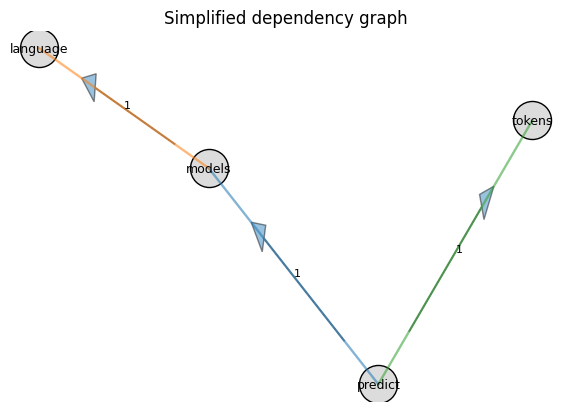

,language,models,predict,tokens
language,0.0,0.0,0.0,0.0
models,1.0,0.0,0.0,0.0
predict,0.0,1.0,0.0,1.0
tokens,0.0,0.0,0.0,0.0


In [3]:
sentence_nodes = ["language", "models", "predict", "tokens"]
dep_edges_directed = [
    ("predict", "models", 1),
    ("models", "language", 1),
    ("predict", "tokens", 1),
]

pos_sentence = {
    "language": (-1.5, 0.7),
    "models": (-0.4, 0.45),
    "predict": (0.7, 0.0),
    "tokens": (1.7, 0.55),
}

A_dep_directed, dep_idx = adjacency_from_edges(sentence_nodes, dep_edges_directed, directed=True)
A_dep_undirected, _ = adjacency_from_edges(sentence_nodes, dep_edges_directed, directed=False)

plot_graph(sentence_nodes, dep_edges_directed, pos_sentence,
           title="Simplified dependency graph", directed=True)

matrix_table(A_dep_directed, sentence_nodes)

### Check direction conventions

If $A_{ij}=1$ means an edge from node $i$ to node $j$, then row $i$ lists outgoing neighbors. Direction conventions differ across software. Always state your convention.

In [4]:
print("Directed adjacency, where row i points to column j:")
display(matrix_table(A_dep_directed, sentence_nodes))

print("Undirected adjacency used for symmetric graph operations:")
display(matrix_table(A_dep_undirected, sentence_nodes))

Directed adjacency, where row i points to column j:


,language,models,predict,tokens
language,0.0,0.0,0.0,0.0
models,1.0,0.0,0.0,0.0
predict,0.0,1.0,0.0,1.0
tokens,0.0,0.0,0.0,0.0


Undirected adjacency used for symmetric graph operations:


,language,models,predict,tokens
language,0.0,1.0,0.0,0.0
models,1.0,0.0,1.0,0.0
predict,0.0,1.0,0.0,1.0
tokens,0.0,0.0,1.0,0.0


## 4. Degree matrix, Laplacian, and graph smoothness

Now use the undirected dependency graph. Its degree and Laplacian matrices are:

$$
D = \operatorname{diag}(A\mathbf 1), \qquad L=D-A.
$$

To see what the Laplacian measures, assign a scalar value to each token. For example, let a signal put large positive values on content words and smaller values on modifiers.

Degree matrix D:


,language,models,predict,tokens
language,1.0,0.0,0.0,0.0
models,0.0,2.0,0.0,0.0
predict,0.0,0.0,2.0,0.0
tokens,0.0,0.0,0.0,1.0


Laplacian L = D - A:


,language,models,predict,tokens
language,1.0,-1.0,0.0,0.0
models,-1.0,2.0,-1.0,0.0
predict,0.0,-1.0,2.0,-1.0
tokens,0.0,0.0,-1.0,1.0


f^T L f from matrix form: 0.11
0.5 * edge sum form: 0.11


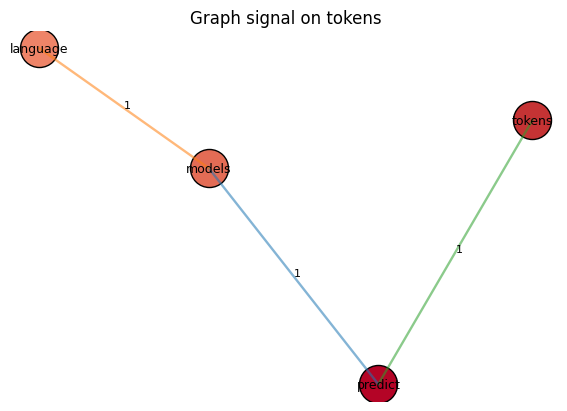

In [5]:
A = A_dep_undirected
D = degree_matrix(A)
L = D - A

print("Degree matrix D:")
display(matrix_table(D, sentence_nodes))

print("Laplacian L = D - A:")
display(matrix_table(L, sentence_nodes))

f = np.array([0.6, 0.7, 1.0, 0.9])
energy_matrix = float(f.T @ L @ f)
energy_edges = 0.5 * sum(A[i, j] * (f[i] - f[j])**2 for i in range(len(f)) for j in range(len(f)))

print("f^T L f from matrix form:", round(energy_matrix, 6))
print("0.5 * edge sum form:", round(energy_edges, 6))

plot_graph(sentence_nodes, dep_edges_directed, pos_sentence, values=f,
           title="Graph signal on tokens", directed=False)

### Interpretation

A graph signal is smooth when connected nodes have similar values. If two syntactically linked words have very different scores, the Laplacian penalty becomes large.

Try modifying `f` in the next cell. Put a very different value on `tokens` and observe how the energy changes.

In [6]:
f_smooth = np.array([0.7, 0.75, 0.8, 0.78])
f_rough = np.array([0.7, 0.75, 0.8, -1.2])

for name, signal in [("smooth", f_smooth), ("rough", f_rough)]:
    print(name, "energy =", round(float(signal.T @ L @ signal), 4))

smooth energy = 0.0054
rough energy = 4.005


## 5. Word co-occurrence graphs

A word co-occurrence graph has one node per word type. Two words are connected if they occur near each other in a corpus.

For a window size $r$, we count pairs satisfying

$$
0 < |s-t| \le r.
$$

This graph is a relational view of the distributional hypothesis: words that appear in similar contexts tend to have related meanings.

In [7]:
corpus = [
    "language models predict tokens",
    "transformer models use attention",
    "attention connects tokens in context",
    "graph models connect words and documents",
    "knowledge graphs connect entities and relations",
    "retrieval connects questions documents and answers",
    "probability models uncertainty in language",
    "tokens words and documents form data",
]

stop = {"and", "in"}

def tokenize(text):
    return [tok.lower() for tok in text.split() if tok.lower() not in stop]

tokenized = [tokenize(doc) for doc in corpus]
word_vocab = sorted(set(tok for doc in tokenized for tok in doc))
word_to_id = {w: i for i, w in enumerate(word_vocab)}

print("Vocabulary size:", len(word_vocab))
print(word_vocab)

Vocabulary size: 24
['answers', 'attention', 'connect', 'connects', 'context', 'data', 'documents', 'entities', 'form', 'graph', 'graphs', 'knowledge', 'language', 'models', 'predict', 'probability', 'questions', 'relations', 'retrieval', 'tokens', 'transformer', 'uncertainty', 'use', 'words']


In [8]:
def cooccurrence_graph(tokenized_docs, vocab, window=2):
    counts = Counter()
    for doc in tokenized_docs:
        for t, center in enumerate(doc):
            for s in range(max(0, t-window), min(len(doc), t+window+1)):
                if s == t:
                    continue
                a, b = center, doc[s]
                if a == b:
                    continue
                u, v = sorted([a, b])
                counts[(u, v)] += 1
    edges = [(u, v, w) for (u, v), w in counts.items()]
    A, idx = adjacency_from_edges(vocab, edges, directed=False)
    return A, edges, idx

A_word, word_edges, word_idx = cooccurrence_graph(tokenized, word_vocab, window=2)

# Show strongest edges.
strong_edges = sorted(word_edges, key=lambda e: (-e[2], e[0], e[1]))[:12]
pd.DataFrame(strong_edges, columns=["word 1", "word 2", "weight"])

,word 1,word 2,weight
0,documents,words,4
1,language,models,4
2,answers,documents,2
3,answers,questions,2
4,attention,connects,2
5,attention,models,2
6,attention,tokens,2
7,attention,use,2
8,connect,documents,2
9,connect,entities,2


### Visualize a selected subgraph

The complete word graph is a little dense. We plot a selected subgraph around important words.

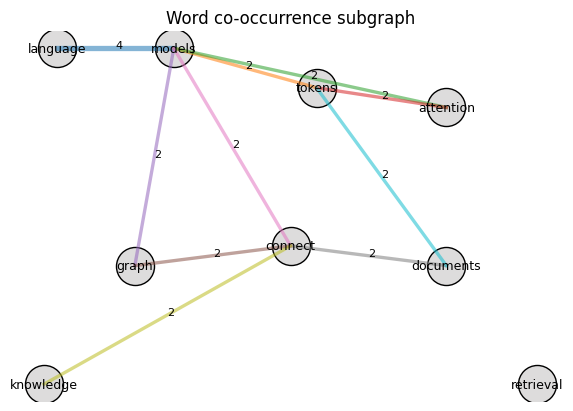

In [9]:
selected = ["language", "models", "tokens", "attention", "graph", "documents", "connect", "retrieval", "knowledge"]
selected_edges = []
for u, v, w in word_edges:
    if u in selected and v in selected and w >= 1:
        selected_edges.append((u, v, w))

pos_word = {
    "language": (-1.8, 0.9),
    "models": (-0.9, 0.9),
    "tokens": (0.2, 0.7),
    "attention": (1.2, 0.6),
    "graph": (-1.2, -0.2),
    "connect": (0.0, -0.1),
    "documents": (1.2, -0.2),
    "retrieval": (1.9, -0.8),
    "knowledge": (-1.9, -0.8),
}

plot_graph(selected, selected_edges, pos_word, title="Word co-occurrence subgraph", directed=False)

## 6. Random walks and PageRank-style centrality

A random walk moves from a node to one of its neighbors with probability proportional to edge weight. The transition matrix is

$$
P = D^{-1}A.
$$

A PageRank-style walk adds a restart distribution $v$:

$$
p_{t+1}=\alpha p_tP + (1-\alpha)v.
$$

This prevents the walk from getting stuck and lets us bias the walk toward a query or topic.

In [10]:
def pagerank(A, alpha=0.85, restart=None, steps=50):
    n = A.shape[0]
    P = transition_matrix(A)
    if restart is None:
        restart = np.ones(n) / n
    else:
        restart = np.asarray(restart, dtype=float)
        restart = restart / restart.sum()
    p = restart.copy()
    history = [p.copy()]
    for _ in range(steps):
        p = alpha * (p @ P) + (1 - alpha) * restart
        history.append(p.copy())
    return p, np.vstack(history)

# Topic-sensitive restart: start near language and models.
restart = np.zeros(len(word_vocab))
for w in ["language", "models"]:
    restart[word_idx[w]] = 1.0

pr, pr_hist = pagerank(A_word, alpha=0.85, restart=restart, steps=80)
ranked = sorted([(word_vocab[i], pr[i]) for i in range(len(word_vocab))], key=lambda x: -x[1])
pd.DataFrame(ranked[:10], columns=["word", "topic-sensitive PageRank"])

,word,topic-sensitive PageRank
0,models,0.242966
1,language,0.142626
2,uncertainty,0.062339
3,tokens,0.060456
4,predict,0.054859
5,connect,0.052227
6,documents,0.042276
7,words,0.041827
8,attention,0.039551
9,use,0.037437


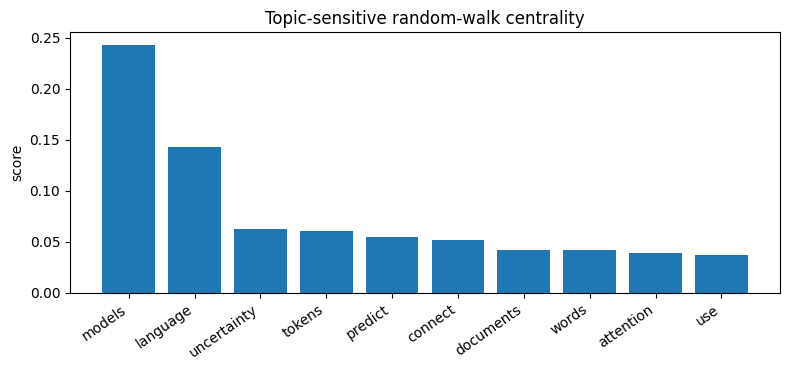

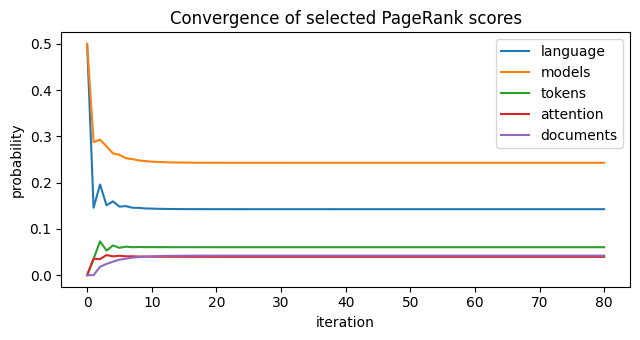

In [11]:
plt.figure(figsize=(8, 3.8))
words = [w for w, _ in ranked[:10]]
scores = [s for _, s in ranked[:10]]
plt.bar(words, scores)
plt.xticks(rotation=35, ha="right")
plt.ylabel("score")
plt.title("Topic-sensitive random-walk centrality")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.5, 3.5))
for w in ["language", "models", "tokens", "attention", "documents"]:
    plt.plot(pr_hist[:, word_idx[w]], label=w)
plt.xlabel("iteration")
plt.ylabel("probability")
plt.title("Convergence of selected PageRank scores")
plt.legend()
plt.tight_layout()
plt.show()

### Reflection

The graph centrality result depends on graph construction. Changing the window size, removing stop words, or using directed edges can change the ranking. Graph algorithms do not remove modeling judgment; they make the modeling judgment explicit.

## 7. Document-term graphs as bipartite graphs

A document-term matrix $X\in R^{m\times d}$ can be interpreted as a bipartite graph. Document nodes connect to term nodes with weights $X_{ij}$.

The bipartite adjacency matrix is

$$
A_{bip}=\begin{bmatrix}0 & X \\ X^T & 0\end{bmatrix}.
$$

Two-step walks recover familiar Gram matrices:

$$
XX^T \quad \text{for document-document similarity},
$$

and

$$
X^TX \quad \text{for term-term similarity}.
$$

In [12]:
docs = [
    "language models use tokens",
    "attention models connect tokens",
    "graphs connect documents and words",
    "retrieval finds documents for questions",
    "knowledge graphs store relations",
]

doc_tokens = [tokenize(doc) for doc in docs]
term_vocab = sorted(set(tok for doc in doc_tokens for tok in doc))
term_to_id = {t: j for j, t in enumerate(term_vocab)}

X = np.zeros((len(docs), len(term_vocab)))
for i, doc in enumerate(doc_tokens):
    for tok in doc:
        X[i, term_to_id[tok]] += 1

doc_names = [f"D{i+1}" for i in range(len(docs))]
print("Document-term matrix:")
display(matrix_table(X, doc_names, term_vocab, digits=0))

DD = X @ X.T
TT = X.T @ X
print("Document-document two-step walk matrix XX^T:")
display(matrix_table(DD, doc_names, doc_names, digits=0))

Document-term matrix:


,attention,connect,documents,finds,for,graphs,knowledge,language,models,questions,relations,retrieval,store,tokens,use,words
D1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
D2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
D3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
D4,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
D5,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


Document-document two-step walk matrix XX^T:


,D1,D2,D3,D4,D5
D1,4.0,2.0,0.0,0.0,0.0
D2,2.0,4.0,1.0,0.0,0.0
D3,0.0,1.0,4.0,1.0,1.0
D4,0.0,0.0,1.0,5.0,0.0
D5,0.0,0.0,1.0,0.0,4.0


In [13]:
# Build the full bipartite adjacency matrix.
zero_docs = np.zeros((X.shape[0], X.shape[0]))
zero_terms = np.zeros((X.shape[1], X.shape[1]))
A_bip = np.block([[zero_docs, X], [X.T, zero_terms]])
all_nodes = doc_names + term_vocab

print("Bipartite adjacency shape:", A_bip.shape)
print("Top-left document-document block is zero because documents do not connect directly.")
display(matrix_table(A_bip[:8, :8], all_nodes[:8], all_nodes[:8], digits=0))

Bipartite adjacency shape: (21, 21)
Top-left document-document block is zero because documents do not connect directly.


,D1,D2,D3,D4,D5,attention,connect,documents
D1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
D3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
D4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
D5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
attention,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
connect,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
documents,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


### Propagation on the bipartite graph

If a user query activates a term node such as `documents`, a random walk can move from terms to documents and then to related terms. This is a graph view of retrieval.

In [14]:
P_bip = transition_matrix(A_bip)
start = np.zeros(len(all_nodes))
start[all_nodes.index("documents")] = 1.0

p = start.copy()
rows = []
for step in range(5):
    top = sorted([(all_nodes[i], p[i]) for i in range(len(all_nodes))], key=lambda x: -x[1])[:6]
    rows.append({"step": step, "top nodes": ", ".join([f"{name}:{score:.2f}" for name, score in top if score > 0])})
    p = p @ P_bip

pd.DataFrame(rows)

,step,top nodes
0,0,documents:1.00
1,1,"D3:0.50, D4:0.50"
2,2,"documents:0.23, connect:0.12, graphs:0.12, wor..."
3,3,"D4:0.51, D3:0.36, D2:0.06, D5:0.06"
4,4,"documents:0.19, connect:0.11, graphs:0.11, fin..."


## 8. Knowledge graphs and relation-specific adjacency matrices

A knowledge graph stores triples

$$
(h,r,t),
$$

where $h$ is a head entity, $r$ is a relation, and $t$ is a tail entity. Relation labels matter. The relation `uses` is not the same as `is_a`.

For each relation type $r$, define a separate adjacency matrix $A^{(r)}$.

In [15]:
triples = [
    ("Transformer", "is_a", "neural_architecture"),
    ("BERT", "is_a", "language_model"),
    ("BERT", "uses", "self_attention"),
    ("Transformer", "uses", "self_attention"),
    ("RAG", "uses", "retrieval"),
    ("RAG", "uses", "generation"),
    ("NLP", "uses", "probability"),
    ("NLP", "uses", "linear_algebra"),
    ("language_model", "predicts", "tokens"),
]

entities = sorted(set([h for h, _, _ in triples] + [t for _, _, t in triples]))
relations = sorted(set(r for _, r, _ in triples))
ent_to_id = {e: i for i, e in enumerate(entities)}

rel_adj = {}
for rel in relations:
    rel_edges = [(h, t, 1) for h, r, t in triples if r == rel]
    rel_adj[rel], _ = adjacency_from_edges(entities, rel_edges, directed=True)

print("Entities:", entities)
print("Relations:", relations)
for rel in relations:
    print("\nRelation:", rel)
    display(matrix_table(rel_adj[rel], entities, entities, digits=0))

Entities: ['BERT', 'NLP', 'RAG', 'Transformer', 'generation', 'language_model', 'linear_algebra', 'neural_architecture', 'probability', 'retrieval', 'self_attention', 'tokens']
Relations: ['is_a', 'predicts', 'uses']

Relation: is_a


,BERT,NLP,RAG,Transformer,generation,language_model,linear_algebra,neural_architecture,probability,retrieval,self_attention,tokens
BERT,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
NLP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RAG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Transformer,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
generation,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
language_model,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
linear_algebra,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
neural_architecture,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
probability,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
retrieval,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Relation: predicts


,BERT,NLP,RAG,Transformer,generation,language_model,linear_algebra,neural_architecture,probability,retrieval,self_attention,tokens
BERT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NLP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RAG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Transformer,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
generation,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
language_model,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
linear_algebra,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
neural_architecture,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
probability,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
retrieval,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Relation: uses


,BERT,NLP,RAG,Transformer,generation,language_model,linear_algebra,neural_architecture,probability,retrieval,self_attention,tokens
BERT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
NLP,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
RAG,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Transformer,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
generation,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
language_model,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
linear_algebra,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
neural_architecture,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
probability,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
retrieval,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Why not collapse all relations?

If we collapse all relation types into one adjacency matrix, we lose meaning. A model may confuse `BERT is_a language_model` with `BERT uses self_attention`. Relation-specific message passing solves this by using different matrices or parameters for different relations.

In [16]:
A_all = sum(rel_adj.values())
print("Collapsed adjacency matrix, ignoring relation labels:")
display(matrix_table(A_all, entities, entities, digits=0))

print("Outgoing neighbors of BERT after collapse:")
bert_i = ent_to_id["BERT"]
for j, w in enumerate(A_all[bert_i]):
    if w > 0:
        print("BERT ->", entities[j])

Collapsed adjacency matrix, ignoring relation labels:


,BERT,NLP,RAG,Transformer,generation,language_model,linear_algebra,neural_architecture,probability,retrieval,self_attention,tokens
BERT,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
NLP,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
RAG,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Transformer,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
generation,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
language_model,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
linear_algebra,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
neural_architecture,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
probability,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
retrieval,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Outgoing neighbors of BERT after collapse:
BERT -> language_model
BERT -> self_attention


## 9. Label propagation

Suppose a few nodes are labeled and the rest are unlabeled. Label propagation repeatedly averages label scores over the graph while restarting from known labels:

$$
F^{(k+1)} = \alpha S F^{(k)} + (1-\alpha)Y.
$$

Here $Y$ stores the initial label scores, $S$ is a normalized adjacency matrix, and $0<\alpha<1$ controls propagation strength.

We will classify words in the co-occurrence graph as either `math-nlp` or `knowledge-retrieval` using only a few seed labels.

In [17]:
classes = ["math-nlp", "knowledge-retrieval"]
seed_labels = {
    "language": "math-nlp",
    "models": "math-nlp",
    "tokens": "math-nlp",
    "knowledge": "knowledge-retrieval",
    "retrieval": "knowledge-retrieval",
    "documents": "knowledge-retrieval",
}

Y = np.zeros((len(word_vocab), len(classes)))
for word, cls in seed_labels.items():
    Y[word_idx[word], classes.index(cls)] = 1.0

S = normalized_adjacency(A_word, add_self_loops=True)
alpha = 0.85
F = Y.copy()
history = []
for k in range(40):
    F = alpha * S @ F + (1 - alpha) * Y
    history.append(F.copy())

label_scores = pd.DataFrame(F, index=word_vocab, columns=classes)
label_scores["predicted"] = [classes[i] for i in np.argmax(F, axis=1)]
label_scores["confidence"] = np.max(F, axis=1)
label_scores.sort_values("confidence", ascending=False).head(15)

,math-nlp,knowledge-retrieval,predicted,confidence
models,0.473756,0.092826,math-nlp,0.473756
language,0.390243,0.042107,math-nlp,0.390243
tokens,0.351440,0.120694,math-nlp,0.351440
documents,0.145325,0.329449,knowledge-retrieval,0.329449
retrieval,0.061437,0.285820,knowledge-retrieval,0.285820
knowledge,0.048865,0.269974,knowledge-retrieval,0.269974
predict,0.230793,0.046634,math-nlp,0.230793
uncertainty,0.217438,0.033159,math-nlp,0.217438
questions,0.078863,0.194504,knowledge-retrieval,0.194504
connects,0.147052,0.179926,knowledge-retrieval,0.179926


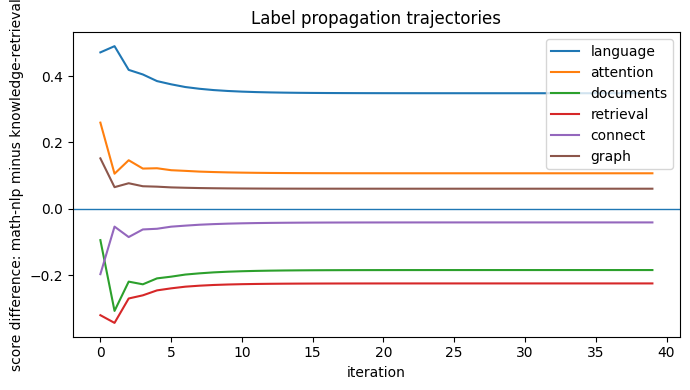

In [18]:
words_to_track = ["language", "attention", "documents", "retrieval", "connect", "graph"]
plt.figure(figsize=(7, 4))
for w in words_to_track:
    vals = [H[word_idx[w], 0] - H[word_idx[w], 1] for H in history]
    plt.plot(vals, label=w)
plt.axhline(0, linewidth=1)
plt.xlabel("iteration")
plt.ylabel("score difference: math-nlp minus knowledge-retrieval")
plt.title("Label propagation trajectories")
plt.legend()
plt.tight_layout()
plt.show()

### Reflection

Label propagation is useful when labels are scarce and graph edges are meaningful. But it can fail when the graph connects different semantic regions too strongly. For example, the word `connect` may bridge several topics and may not belong cleanly to either label.

## 10. Graph convolution as smoothing plus learning

A simplified graph convolution layer is

$$
H' = \sigma(\tilde S H W),
$$

where:

- $H\in R^{n\times d}$ stores node features;
- $\tilde S$ is a normalized adjacency matrix with self-loops;
- $W\in R^{d\times d'}$ is a trainable weight matrix;
- $\sigma$ is a nonlinear activation.

The matrix $\tilde S$ mixes neighboring node features. The matrix $W$ transforms feature coordinates.

In [19]:
def relu(X):
    return np.maximum(X, 0)

# Create simple node features for the selected word subgraph.
selected_idx = [word_idx[w] for w in selected]
A_sel = A_word[np.ix_(selected_idx, selected_idx)]
S_sel = normalized_adjacency(A_sel, add_self_loops=True)

# Features: [is seeded math-nlp, is seeded knowledge-retrieval, degree in selected graph]
H0 = np.zeros((len(selected), 3))
for i, w in enumerate(selected):
    if seed_labels.get(w) == "math-nlp":
        H0[i, 0] = 1.0
    if seed_labels.get(w) == "knowledge-retrieval":
        H0[i, 1] = 1.0
H0[:, 2] = A_sel.sum(axis=1)
H0[:, 2] = H0[:, 2] / max(1, H0[:, 2].max())

W = rng.normal(scale=0.6, size=(3, 2))
H1 = relu(S_sel @ H0 @ W)

print("Input features H0:")
display(pd.DataFrame(np.round(H0, 3), index=selected, columns=["math seed", "retrieval seed", "degree"]))

print("After one graph-convolution layer H1:")
display(pd.DataFrame(np.round(H1, 3), index=selected, columns=["feature 1", "feature 2"]))

Input features H0:


,math seed,retrieval seed,degree
language,1.0,0.0,0.333
models,1.0,0.0,1.000
tokens,1.0,0.0,0.500
attention,0.0,0.0,0.333
graph,0.0,0.0,0.333
documents,0.0,1.0,0.333
connect,0.0,0.0,0.667
retrieval,0.0,1.0,0.000
knowledge,0.0,1.0,0.167


After one graph-convolution layer H1:


,feature 1,feature 2
language,0.000,0.986
models,0.000,1.112
tokens,0.000,0.539
attention,0.000,0.841
graph,0.123,0.679
documents,0.000,0.534
connect,0.000,0.263
retrieval,0.000,0.000
knowledge,0.000,0.137


### Oversmoothing

Repeated multiplication by a normalized adjacency matrix makes node features increasingly similar. This phenomenon is called oversmoothing. It is one reason deep graph neural networks require careful design.

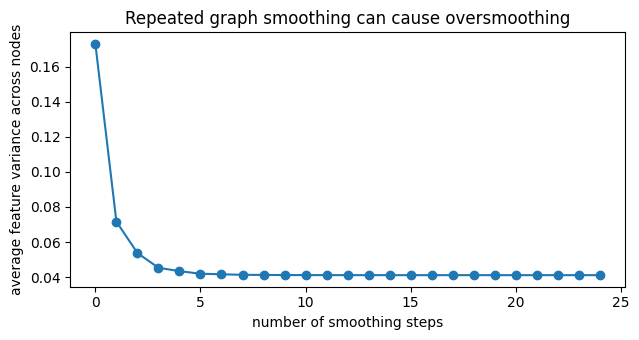

,math seed,retrieval seed,degree
language,0.365,0.171,0.439
models,0.588,0.275,0.707
tokens,0.432,0.202,0.519
attention,0.365,0.171,0.439
graph,0.365,0.171,0.439


In [20]:
H = H0.copy()
variances = []
for layer in range(25):
    variances.append(float(np.mean(np.var(H, axis=0))))
    H = S_sel @ H

plt.figure(figsize=(6.5, 3.5))
plt.plot(variances, marker="o")
plt.xlabel("number of smoothing steps")
plt.ylabel("average feature variance across nodes")
plt.title("Repeated graph smoothing can cause oversmoothing")
plt.tight_layout()
plt.show()

pd.DataFrame(np.round(H, 3), index=selected, columns=["math seed", "retrieval seed", "degree"]).head()

## 11. Graph attention

Graph attention restricts attention to graph neighborhoods. For node $i$, compute a score for each neighbor $j$:

$$
e_{ij}=a(h_i,h_j).
$$

Then normalize over neighbors:

$$
\alpha_{ij}=\frac{\exp(e_{ij})}{\sum_{k\in N(i)}\exp(e_{ik})}.
$$

The node update is

$$
h'_i=\sum_{j\in N(i)}\alpha_{ij}Wh_j.
$$

This is self-attention on a sparse graph rather than on a complete sequence.

In [21]:
# Use selected graph with self-loops.
A_att = A_sel.copy()
A_att = A_att + np.eye(A_att.shape[0])
mask = A_att > 0

# Node features H0. Project them into query/key/value coordinates.
d_in = H0.shape[1]
d_model = 4
Wq = rng.normal(scale=0.5, size=(d_in, d_model))
Wk = rng.normal(scale=0.5, size=(d_in, d_model))
Wv = rng.normal(scale=0.5, size=(d_in, d_model))

Q = H0 @ Wq
K = H0 @ Wk
V = H0 @ Wv
scores = Q @ K.T / np.sqrt(d_model)
alpha_att = stable_softmax_rows(scores, mask=mask)
H_att = alpha_att @ V

print("Graph attention weights. Rows attend only to graph neighbors plus self-loops.")
display(pd.DataFrame(np.round(alpha_att, 3), index=selected, columns=selected))

print("Output representations from one graph-attention layer:")
display(pd.DataFrame(np.round(H_att, 3), index=selected))

Graph attention weights. Rows attend only to graph neighbors plus self-loops.


,language,models,tokens,attention,graph,documents,connect,retrieval,knowledge
language,0.510,0.490,0.000,0.000,0.000,0.000,0.000,0.0,0.000
models,0.169,0.159,0.166,0.170,0.170,0.000,0.165,0.0,0.000
tokens,0.000,0.247,0.255,0.274,0.000,0.224,0.000,0.0,0.000
attention,0.000,0.335,0.337,0.327,0.000,0.000,0.000,0.0,0.000
graph,0.000,0.339,0.000,0.000,0.331,0.000,0.330,0.0,0.000
documents,0.000,0.000,0.267,0.000,0.000,0.396,0.337,0.0,0.000
connect,0.000,0.223,0.000,0.000,0.212,0.177,0.210,0.0,0.178
retrieval,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.0,0.000
knowledge,0.000,0.000,0.000,0.000,0.000,0.000,0.448,0.0,0.552


Output representations from one graph-attention layer:


,0,1,2,3
language,-0.681,0.565,-0.156,0.045
models,-0.359,0.242,-0.079,0.051
tokens,-0.441,0.363,-0.170,0.065
attention,-0.478,0.348,-0.107,0.055
graph,-0.282,0.109,-0.057,0.081
documents,-0.350,0.301,-0.203,0.078
connect,-0.313,0.242,-0.180,0.083
retrieval,-0.334,0.526,-0.400,0.049
knowledge,-0.229,0.218,-0.225,0.085


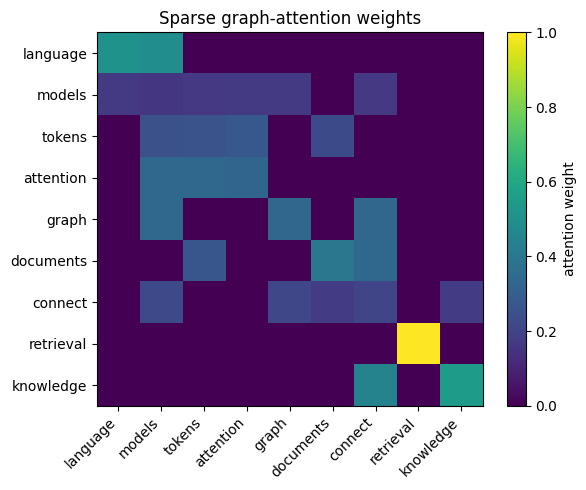

In [22]:
plt.figure(figsize=(6, 5))
plt.imshow(alpha_att, aspect="auto")
plt.colorbar(label="attention weight")
plt.xticks(range(len(selected)), selected, rotation=45, ha="right")
plt.yticks(range(len(selected)), selected)
plt.title("Sparse graph-attention weights")
plt.tight_layout()
plt.show()

### Compare graph attention with full self-attention

Full self-attention lets every node attend to every other node. Graph attention permits only edges in the graph. This is both a computational restriction and a modeling assumption.

In [23]:
full_alpha = stable_softmax_rows(scores, mask=np.ones_like(mask, dtype=bool))

print("Average entropy of full attention:", round(float(-np.sum(full_alpha * np.log(full_alpha + 1e-12), axis=1).mean()), 3))
print("Average entropy of graph attention:", round(float(-np.sum(alpha_att * np.log(alpha_att + 1e-12), axis=1).mean()), 3))

comparison = pd.DataFrame({
    "node": selected,
    "available keys in full attention": [len(selected)] * len(selected),
    "available keys in graph attention": mask.sum(axis=1),
})
comparison

Average entropy of full attention: 2.189
Average entropy of graph attention: 1.049


,node,available keys in full attention,available keys in graph attention
0,language,9,2
1,models,9,6
2,tokens,9,4
3,attention,9,3
4,graph,9,3
5,documents,9,3
6,connect,9,5
7,retrieval,9,1
8,knowledge,9,2


## 12. Relational message passing for knowledge graphs

Knowledge graphs have relation types. A simple relational layer is

$$
h'_i = \sigma\left(W_0h_i + \sum_r \sum_{j\in N_r(i)} \frac{1}{c_{i,r}} W_rh_j\right).
$$

The key idea is that each relation type can have its own transformation $W_r$.

In the code below, messages travel along incoming edges: if $j \to i$, then $j$ sends information to $i$ through the relation-specific matrix.

In [24]:
entity_features = rng.normal(scale=0.5, size=(len(entities), 3))
W0 = rng.normal(scale=0.4, size=(3, 2))
Wr = {rel: rng.normal(scale=0.4, size=(3, 2)) for rel in relations}

H_rel = entity_features @ W0
for rel in relations:
    Arel = rel_adj[rel]
    # Incoming aggregation: Arel.T @ features collects sources for each target.
    incoming_counts = Arel.sum(axis=0, keepdims=True).T
    agg = Arel.T @ entity_features
    agg = np.divide(agg, incoming_counts, out=np.zeros_like(agg), where=incoming_counts > 0)
    H_rel += agg @ Wr[rel]
H_rel = np.tanh(H_rel)

pd.DataFrame(np.round(H_rel, 3), index=entities, columns=["rel feature 1", "rel feature 2"])

,rel feature 1,rel feature 2
BERT,-0.082,-0.406
NLP,0.457,0.436
RAG,0.237,0.285
Transformer,-0.661,-0.897
generation,0.025,0.136
language_model,-0.227,0.415
linear_algebra,-0.054,0.261
neural_architecture,-0.474,-0.827
probability,-0.574,-0.931
retrieval,-0.329,-0.484


### Relation audit

A good audit question is:

> Which relation types should share parameters, and which should remain separate?

For a very small knowledge graph, relation-specific parameters may overfit. For a large graph, collapsing relations may destroy important semantics. The modeling choice depends on data size, relation meaning, and the downstream task.

## 13. Graph construction choices: a small experiment

The same corpus can produce different word graphs depending on window size. We compare PageRank centrality for window sizes $1$, $2$, and $3$.

In [25]:
rows = []
for window in [1, 2, 3]:
    A_w, edges_w, idx_w = cooccurrence_graph(tokenized, word_vocab, window=window)
    restart_w = np.zeros(len(word_vocab))
    for w in ["language", "models"]:
        restart_w[idx_w[w]] = 1.0
    pr_w, _ = pagerank(A_w, alpha=0.85, restart=restart_w, steps=80)
    top = sorted([(word_vocab[i], pr_w[i]) for i in range(len(word_vocab))], key=lambda x: -x[1])[:8]
    rows.append({
        "window": window,
        "top words": ", ".join([w for w, _ in top])
    })

pd.DataFrame(rows)

,window,top words
0,1,"models, language, uncertainty, connect, use, p..."
1,2,"models, language, uncertainty, tokens, predict..."
2,3,"models, language, tokens, documents, words, pr..."


## 14. Implementation checklist

When you build a graph NLP model, check the following:

1. **Node choice.** Are nodes tokens, word types, documents, passages, entities, users, or courses?
2. **Edge choice.** Are edges syntactic, semantic, co-occurrence, retrieval, citation, or membership relations?
3. **Direction.** Does $A_{ij}$ mean $i\to j$ or $j\to i$?
4. **Weighting.** Are weights counts, probabilities, similarities, PMI values, or learned scores?
5. **Normalization.** Are you using $D^{-1}A$, $D^{-1/2}AD^{-1/2}$, or unnormalized adjacency?
6. **Self-loops.** Should a node preserve its own features during message passing?
7. **Relation types.** Should different edge labels use different parameters?
8. **Oversmoothing.** Does repeated propagation erase useful distinctions?
9. **Leakage.** Does your graph accidentally connect train and test labels in a way that leaks information?
10. **Interpretability.** Can you explain what a high score or propagated label means?

## 15. Exercises

### Exercise 1 — Change the dependency graph

Modify the dependency graph for another four- or five-word sentence. Build its directed and undirected adjacency matrices. Compute its Laplacian.

### Exercise 2 — Verify the Laplacian identity

Create a random graph signal $f$ on the word graph. Verify numerically that

$$
f^TLf = \frac{1}{2}\sum_{i,j} A_{ij}(f_i-f_j)^2.
$$

### Exercise 3 — Window-size sensitivity

Rebuild the co-occurrence graph with window sizes $1$, $2$, and $4$. Which central words are stable? Which change?

### Exercise 4 — Personalized PageRank

Create a restart distribution focused on `knowledge` and `retrieval`. Compare the top ranked words with the restart distribution focused on `language` and `models`.

### Exercise 5 — Label propagation audit

Add one incorrect seed label. For example, label `coffee` or another unrelated word if you add it to the corpus. How does the error spread?

### Exercise 6 — Graph attention mask

Remove the graph mask from the graph-attention layer. How do the attention weights change? What modeling assumption changes?

### Exercise 7 — Relational graph design

Add a relation type `related_to` to the knowledge graph. Should it share parameters with `uses` or have its own matrix? Explain.

## 16. Mini-project — Build a graph for a small advising or course-resource corpus

Create a small graph for a realistic NLP task. For example, build a graph for course advising resources.

Possible node types:

- courses;
- topics;
- prerequisites;
- student questions;
- official resources;
- program requirements.

Possible edge types:

- `requires`;
- `covers_topic`;
- `answers_question`;
- `similar_to`;
- `part_of_program`.

Your project should include:

1. a clear definition of nodes and edge types;
2. at least one adjacency matrix or relation-specific adjacency tensor;
3. one graph algorithm such as PageRank, label propagation, or graph attention;
4. a short explanation of why graph structure helps more than a bag-of-words representation;
5. an audit of one failure mode.

## 17. AI-assisted learning prompts

Use an AI assistant as a tutor or reviewer, not as a replacement for your reasoning.

Try these prompts:

1. "Here is my graph construction for an NLP task. Identify possible information leakage or wrong edge directions."
2. "Explain the difference between $D^{-1}A$ and $D^{-1/2}AD^{-1/2}$ using my example graph."
3. "I used a word co-occurrence graph with window size 5. What assumptions does that impose?"
4. "Review my label propagation experiment and suggest a diagnostic for oversmoothing."
5. "Given these knowledge graph relations, which should have separate message-passing parameters?"

Always check the mathematical details yourself. Graph mistakes are often subtle because the code may run even when the modeling convention is wrong.

## Summary

In this lab, you built graph representations for NLP and implemented core graph algorithms from scratch.

You saw that:

- adjacency matrices encode linguistic relations;
- Laplacians measure graph smoothness;
- co-occurrence graphs connect distributional semantics with graph theory;
- document-term matrices are bipartite graphs;
- knowledge graphs require relation-specific structure;
- random walks and PageRank rank nodes by graph connectivity;
- label propagation spreads supervision through graph edges;
- graph convolution mixes neighboring features;
- graph attention is sparse attention over graph neighborhoods;
- graph construction is a modeling decision, not merely preprocessing.

The central lesson is that graphs are useful when relationships are part of the linguistic signal.